In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import matplotlib.pyplot as plt
import xarray as xr

import cartopy.crs as ccrs



In [3]:
is_local_data = False
Month_idx = 4
safe = False
start = None
end = None
max_depth = 3


### Load parameters of the transformations

In [4]:
max_keys = ["emp","emp_plus1","emp_plus5","emp_plus10","emp_plus15","Teo_min","Teo_min_plus5","Teo_min_plus10","Teo_min_plus15","mon_plus5","mon_plus10","trash"]

In [5]:
parameter_sets = {}
for key in max_keys:
    parameter_sets[f"{key}_max"] = model.loading.load_params(var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/Maximas/{key}/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")

the mask should only change if one is based on relative data, and one is abs because the threshold has a diffrent effect

In [6]:
for key in max_keys:
    print(parameter_sets["emp_plus10_max"]["detail_mask"].equals(parameter_sets[f"{key}_max"]["detail_mask"]))


True
True
True
True
True
True
True
True
True
True
True
True


In [7]:
for key in max_keys:
    print(parameter_sets["emp_plus10_max"]["chunk_mask"].equals(parameter_sets[f"{key}_max"]["chunk_mask"]))


True
True
True
True
True
True
True
True
True
True
True
True


In [8]:
chunk_mask = parameter_sets["emp_plus10_max"]["chunk_mask"]
detal_mask = parameter_sets["emp_plus10_max"]["detail_mask"]


### Load test input

In [9]:
run_idx = 4

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=run_idx)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=run_idx)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### shape inputs

In [10]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds


In [11]:
input = shape_input(raw_input_for_test, chunk_mask.mrsol)

### Emulate

In [12]:
predictions = {}

In [13]:
for max_key in max_keys:
    for mot_key in ["mean","variance"]:
        LinReg = model.stats._parallel_linear_regression.ParLinearRegression()
        LinReg = LinReg.from_params(parameter_sets[f"{max_key}_max"][mot_key])
        if mot_key == "skew":
            predictions[f"{max_key}_{mot_key}"] = LinReg.predict(input).transpose("gridcell","time", "depth").clip(min=-0.995,max=0.995)
        if mot_key == "variance":
            predictions[f"{max_key}_{mot_key}"] = LinReg.predict(input).transpose("gridcell","time", "depth").clip(min=1e-32)
        else:
            predictions[f"{max_key}_{mot_key}"] = LinReg.predict(input).transpose("gridcell","time", "depth")

### maximas

In [14]:
maxima_versions = {}

In [15]:
for key in max_keys :
    max = model.mask.mask_mask(parameter_sets[f"{key}_max"]["local_maximas"],parameter_sets[f"{key}_max"]["chunk_mask"].mrsol).isel(depth=slice(0, max_depth))
    maxima_versions[f"{key}_max"] = mesmer.grid.stack_lat_lon(max).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol


### load and shape targets

In [16]:
def shape_target(ds):
    #ds = ds.clip(min = 1e-32)
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth)).drop_vars("depth_bnds")
    return ds

In [17]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds)
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds

In [18]:
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=run_idx)


In [19]:
target_unstacked = shape_target(raw_mrsol_for_test)
target = mask_stack_target(target_unstacked)

#### Scores

In [20]:
score_sets = {}


In [21]:
score_keys = max_keys

In [22]:
for key in max_keys:
    score_sets[key] = model_analysis.crps_score.crps_norm_score(predictions[f"{key}_mean"],predictions[f"{key}_variance"], target, transformation = "Logit", maximas_da = maxima_versions[f"{key}_max"],ensemble_size = 15)

In [23]:
for s_keys, scores in score_sets.items():
    score_sets[s_keys] = mesmer.grid.unstack_lat_lon_and_align(scores, target_unstacked)
    
    score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],detal_mask.mrsol,"lon", "lat", "depth")
    

In [24]:
all_scores_ds =xr.Dataset({key : score.crps_score for key, score in score_sets.items()})

In [25]:
all_scores_ds.mean(dim=["lon","lat","time"])

<xarray.Dataset> Size: 312B
Dimensions:         (depth: 3)
Coordinates:
  * depth           (depth) float64 24B 0.03 0.19 0.78
Data variables:
    emp             (depth) float64 24B 0.4483 1.776 7.354
    emp_plus1       (depth) float64 24B 0.4172 1.651 6.771
    emp_plus5       (depth) float64 24B 0.4161 1.643 6.732
    emp_plus10      (depth) float64 24B 0.4176 1.641 6.722
    emp_plus15      (depth) float64 24B 0.4193 1.645 6.721
    Teo_min         (depth) float64 24B 0.4333 1.7 6.926
    Teo_min_plus5   (depth) float64 24B 0.4191 1.642 6.72
    Teo_min_plus10  (depth) float64 24B 0.4203 1.644 6.715
    Teo_min_plus15  (depth) float64 24B 0.4215 1.645 6.718
    mon_plus5       (depth) float64 24B 0.4165 1.649 6.769
    mon_plus10      (depth) float64 24B 0.4158 1.645 6.743
    trash           (depth) float64 24B 0.4493 1.672 6.809

In [26]:
all_scores_ds.mean(dim=["lon","lat","time"])-all_scores_ds.mean(dim=["lon","lat","time"]).emp_plus10

<xarray.Dataset> Size: 312B
Dimensions:         (depth: 3)
Coordinates:
  * depth           (depth) float64 24B 0.03 0.19 0.78
Data variables:
    emp             (depth) float64 24B 0.03073 0.135 0.6319
    emp_plus1       (depth) float64 24B -0.0004042 0.01046 0.0486
    emp_plus5       (depth) float64 24B -0.001445 0.001614 0.009681
    emp_plus10      (depth) float64 24B 0.0 0.0 0.0
    emp_plus15      (depth) float64 24B 0.001679 0.003551 -0.0009756
    Teo_min         (depth) float64 24B 0.01572 0.05895 0.2037
    Teo_min_plus5   (depth) float64 24B 0.001563 0.0007196 -0.00236
    Teo_min_plus10  (depth) float64 24B 0.002729 0.003104 -0.006835
    Teo_min_plus15  (depth) float64 24B 0.00388 0.003945 -0.00462
    mon_plus5       (depth) float64 24B -0.001049 0.008321 0.04694
    mon_plus10      (depth) float64 24B -0.001758 0.004361 0.02092
    trash           (depth) float64 24B 0.03175 0.03075 0.08702

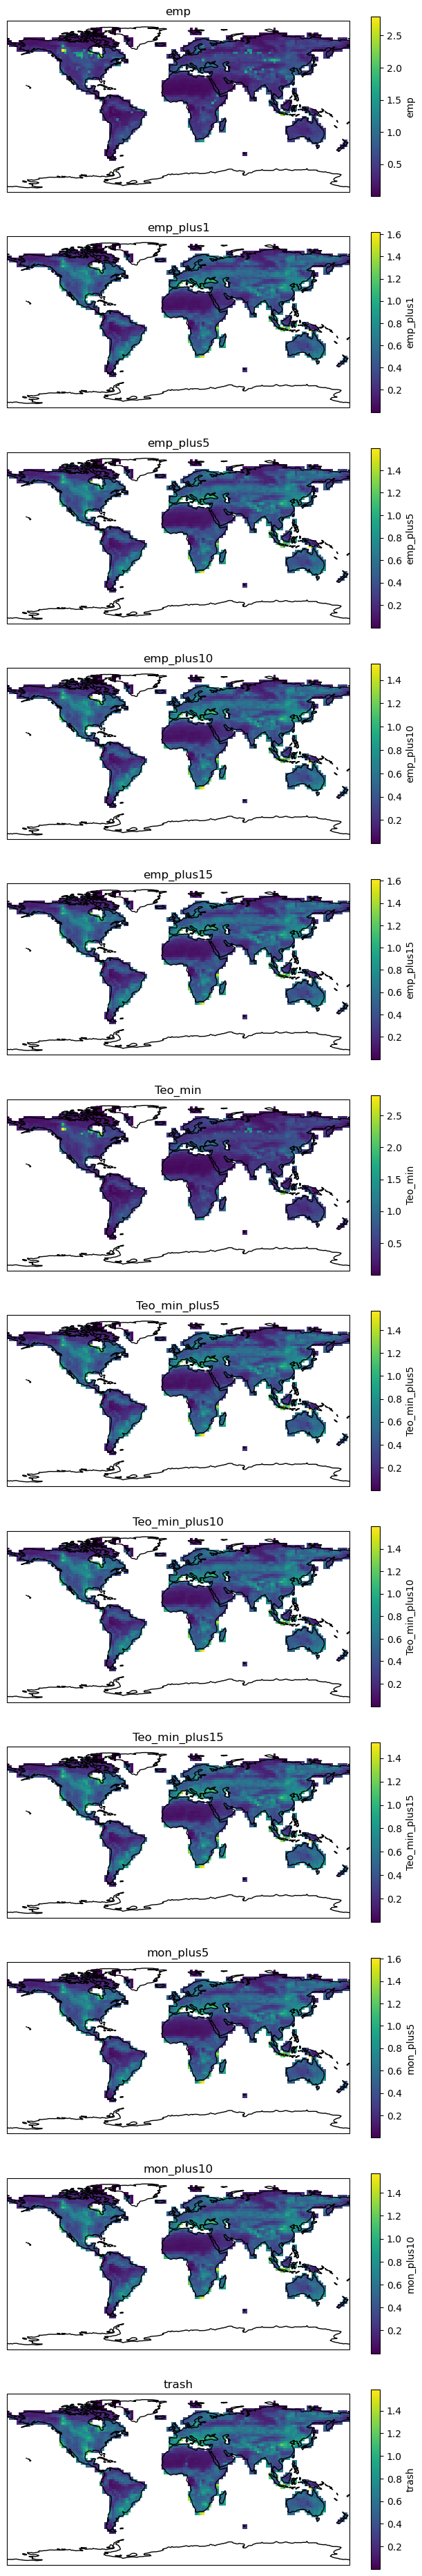

In [27]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=len(max_keys),
    ncols=1,
    figsize=(8, 4*len(max_keys))
)
depth = 0

for i, s_key in enumerate(score_keys):
    da = all_scores_ds.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[i])
    ax[i].coastlines()
    ax[i].set_title(s_key)



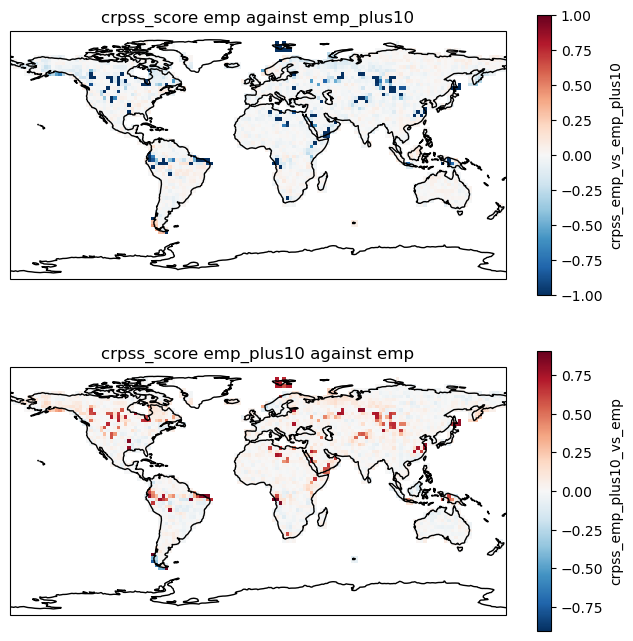

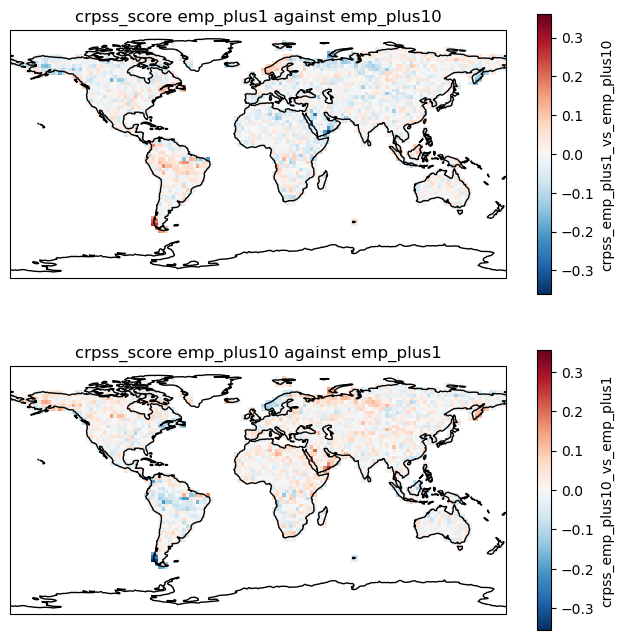

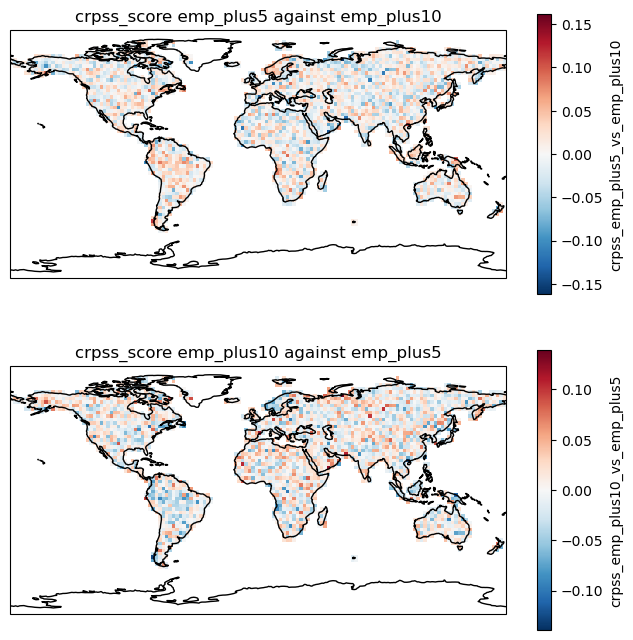

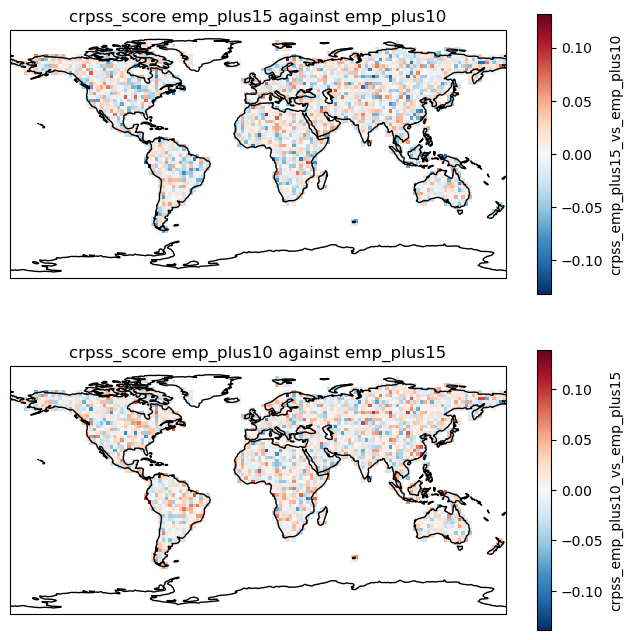

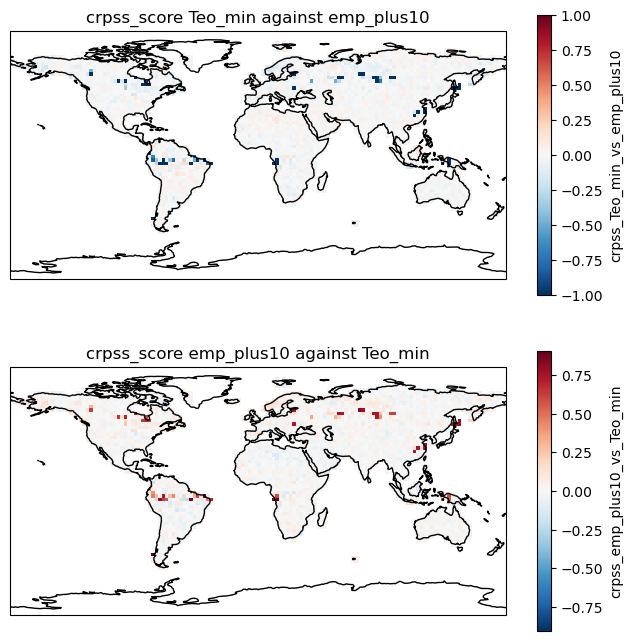

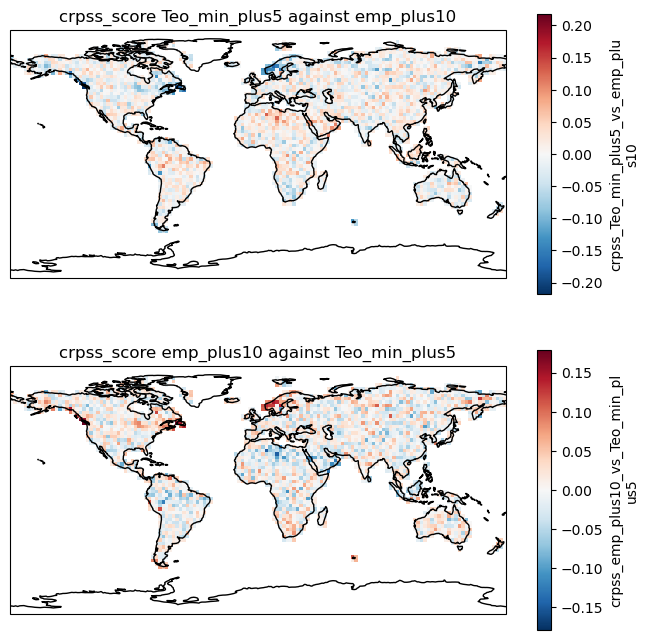

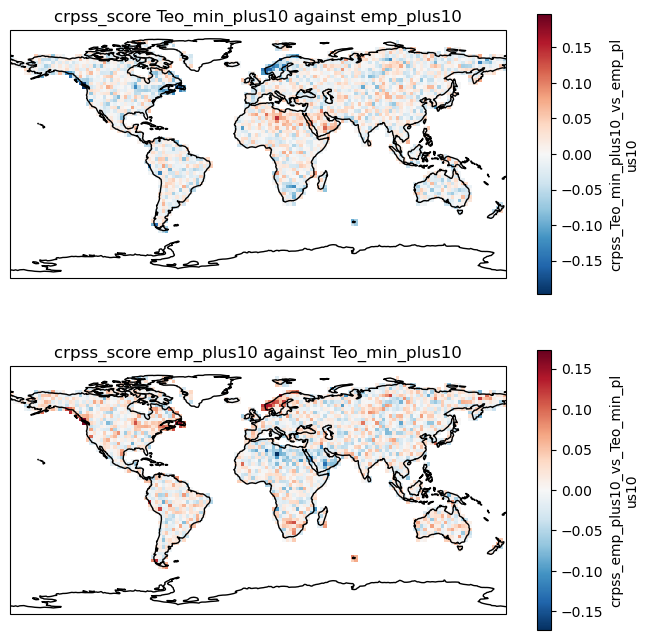

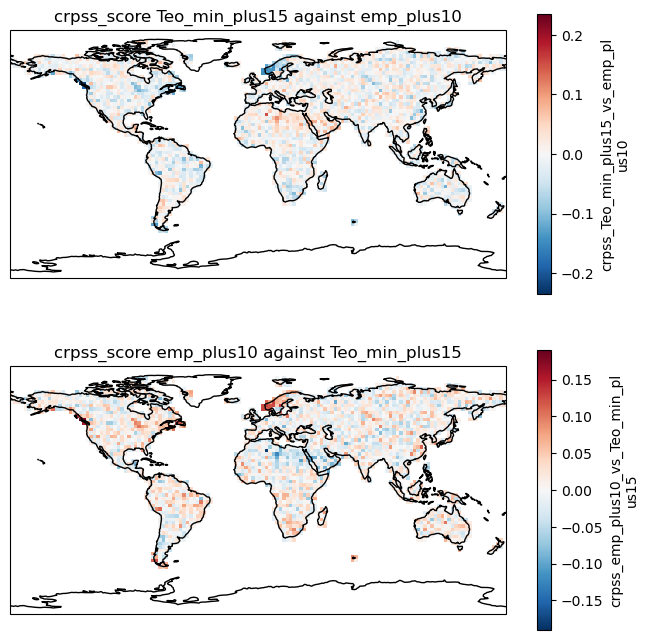

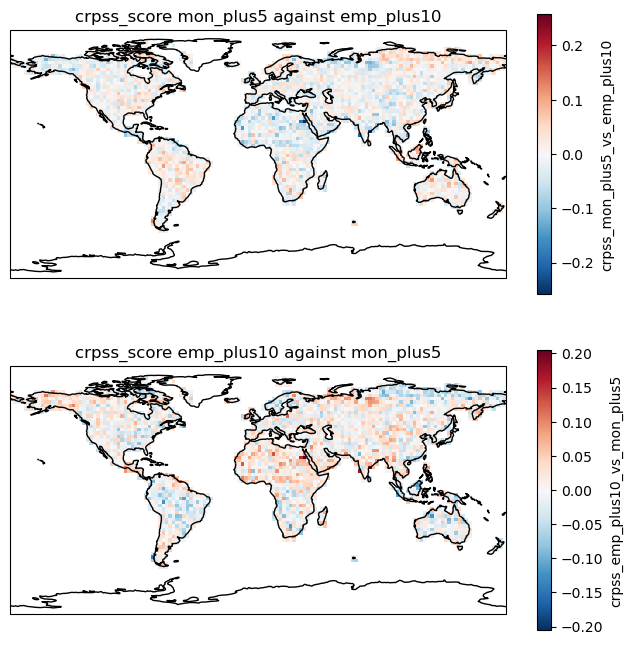

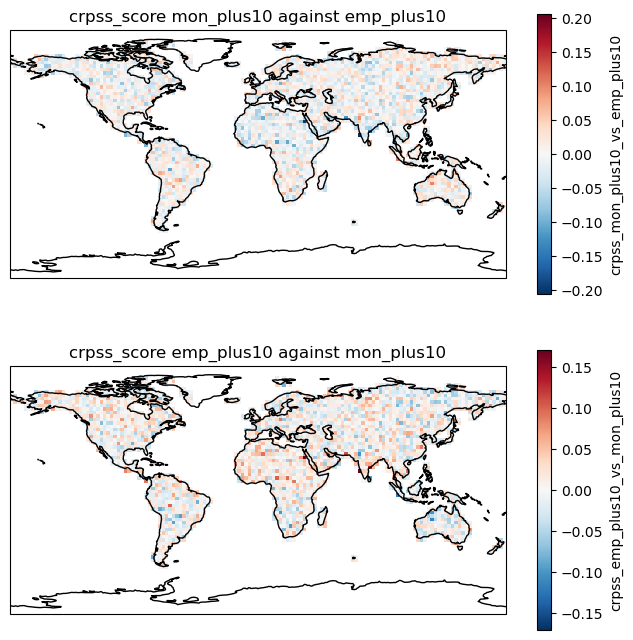

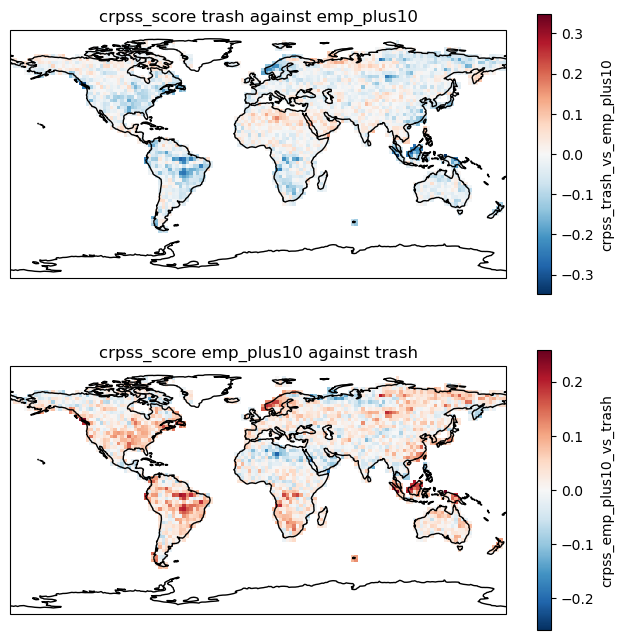

In [28]:
depth = 1

choice = "emp_plus10"

for i, s_key in enumerate(score_keys):
    if s_key == choice:
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets[choice].crps_score,score_sets[s_key].crps_score,choice,s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=2,
    ncols=1,
    figsize=(8, 8)
    )
    """
    da = vs.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(s_key)

    da = vs.isel(depth=depth).mean("time")[choice]
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(choice)
    """
    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_{choice}"].clip(min=-1)
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(f"crpss_score {s_key} against {choice}")

    da = vs.isel(depth=depth)[f"crpss_{choice}_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(f"crpss_score {choice} against {s_key}")

    fig_global_crpss.show()
    
